# cool_maps Tutorial

`cool_maps` is a small plotting toolbox built on top of [Cartopy](https://scitools.org.uk/cartopy/docs/latest/)
and (optionally) [Basemap](https://matplotlib.org/basemap/), written to make it fast to produce
nice-looking oceanographic maps: coastlines, bathymetry, currents, and your own data overlaid on top.

This notebook is a complete, runnable walkthrough. It assumes you have `cool_maps` installed
(`conda install -c conda-forge cool_maps`, or `pip install .` from a source checkout -- see the
project [README](https://github.com/rucool/cool_maps) for details).

**Contents**

1. [Setup](#1.-Setup)
2. [Your first map](#2.-Your-first-map)
3. [Projections](#3.-Projections)
4. [Coastline resolution](#4.-Coastline-resolution)
5. [Colors](#5.-Colors)
6. [Ticks and gridlines](#6.-Ticks-and-gridlines)
7. [Bathymetry](#7.-Bathymetry)
8. [Overlaying your own data](#8.-Overlaying-your-own-data)
9. [Ocean currents](#9.-Ocean-currents)
10. [Choosing between Cartopy and Basemap](#10.-Choosing-between-Cartopy-and-Basemap)
11. [Building a map piece by piece](#11.-Building-a-map-piece-by-piece)
12. [Saving your figures](#12.-Saving-your-figures)
13. [Where to go next](#13.-Where-to-go-next)


---
## 1. Setup

Everything in `cool_maps` for making maps lives in `cool_maps.plot`, conventionally imported as `cplt`.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import cool_maps.plot as cplt

# Which mapping engines are importable in this environment, and which is active?
print("Available engines:", cplt.available_engines())
print("Active engine:    ", cplt.get_engine())


Available engines: ('cartopy', 'basemap')
Active engine:     cartopy


If `available_engines()` only shows `('cartopy',)`, that's fine -- Cartopy is the default and only
required engine. Basemap is optional; see [Section 10](#10.-Choosing-between-Cartopy-and-Basemap) for
how to install and use it. Everything through Section 9 works identically either way.


---
## 2. Your first map

Every map starts with an **extent**: the bounding box you want to plot, as `(lon_min, lon_max, lat_min, lat_max)`.

The only required argument to `cplt.create()` is `extent`. Everything else has a sensible default:
tan land, blue ocean, black coastlines, automatically spaced ticks, and rivers/lakes/state and country
borders drawn in for you.


In [2]:
# Gulf of Mexico
extent = [-99, -79, 18, 31]


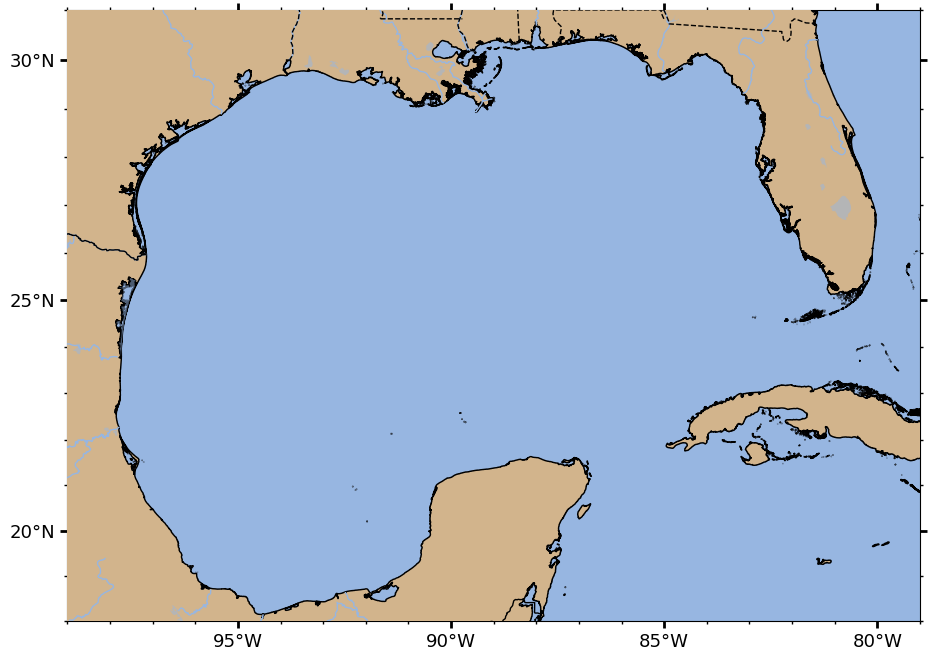

In [3]:
fig, ax = cplt.create(extent)
plt.show()


`create()` returns `(fig, ax)` when it builds a new figure for you (as above), or just `ax` if you pass
in an existing axes with `ax=`. `ax` is a normal matplotlib axes -- you can call any standard matplotlib
method on it (`ax.set_title(...)`, `ax.legend()`, etc.) in addition to the `cool_maps`-specific behavior
described below.


---
## 3. Projections

Pass `proj=` to pick a map projection. `cool_maps` accepts either a plain string (works under any engine)
or, if you're using Cartopy, a real `cartopy.crs` object for full control.

Supported projection strings: `"platecarree"`, `"mercator"` (the default), `"lambertcylindrical"`,
`"mill"`, `"orthographic"`, `"lambertconformal"`, `"stereographic"`, `"azimuthequidistant"`.


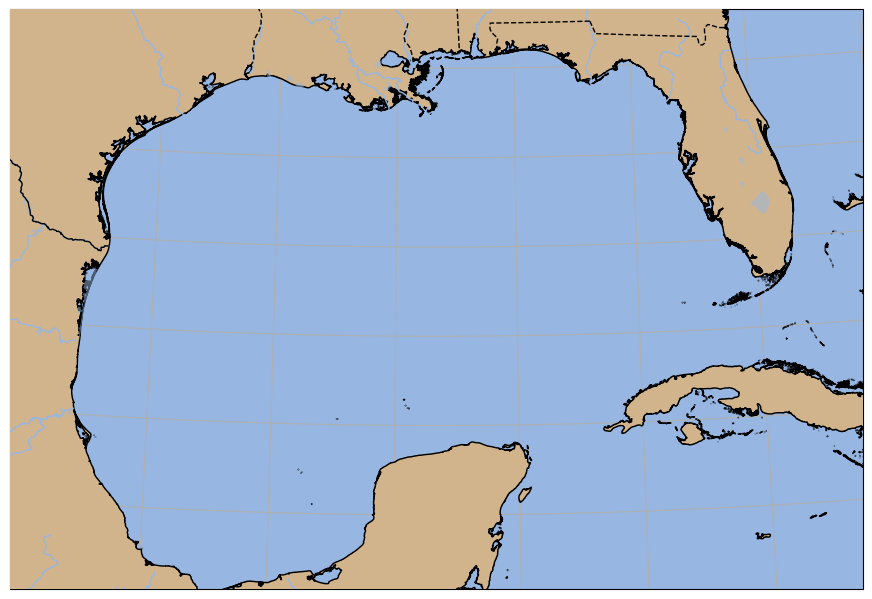

In [4]:
fig, ax = cplt.create(extent, proj="lambertconformal", ticks=False, gridlines=True)
plt.show()


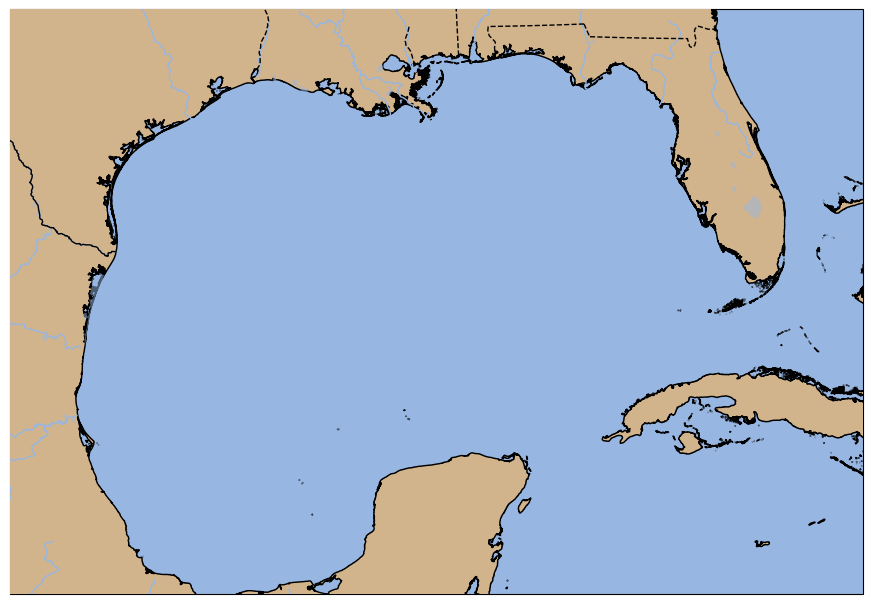

In [5]:
# If you're using the Cartopy engine, you can also pass a real CRS object for full control
# over projection parameters that the shared string form doesn't expose.
import cartopy.crs as ccrs

fig, ax = cplt.create(extent, proj=ccrs.AlbersEqualArea(central_longitude=-89), ticks=False)
plt.show()


---
## 4. Coastline resolution

`coast=` controls how detailed the coastline/land polygons are. Higher resolution looks better for
regional maps but is slower to render -- especially the first time, since the underlying coastline
dataset has to be loaded.

| `coast=`  | Use for |
|-----------|---------|
| `"full"`  | Regional/coastal maps needing maximum detail (the default) |
| `"high"`  | Regional maps where "full" is too slow |
| `"mid"`   | Basin-scale maps |
| `"low"`   | Ocean-basin or global maps |
| `"crude"` | Quick previews; omits rivers/state borders |


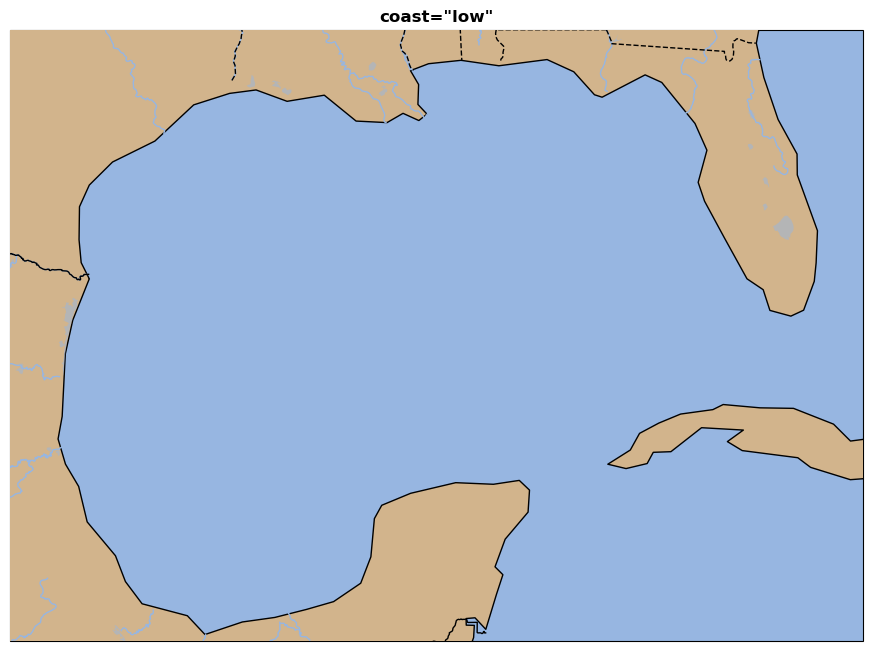

In [6]:
fig, ax = cplt.create(extent, coast="low", ticks=False)
ax.set_title('coast="low"', fontweight="bold")
plt.show()


---
## 5. Colors

Three keywords control the map's color palette, independent of engine or projection:

- `landcolor` -- fill color for land (default `"tan"`)
- `oceancolor` -- fill color for water (default: a Cartopy-style ocean blue)
- `edgecolor` -- coastline/border line color (default `"black"`)


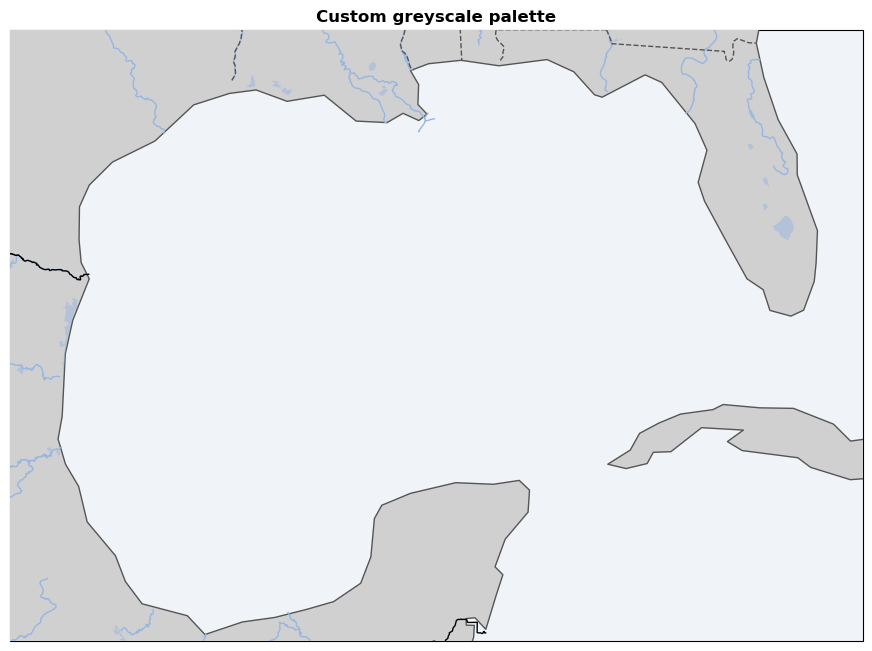

In [7]:
fig, ax = cplt.create(
    extent,
    coast="low",
    ticks=False,
    landcolor="#d0d0d0",
    oceancolor="#f0f4f8",
    edgecolor="#555555",
)
ax.set_title("Custom greyscale palette", fontweight="bold")
plt.show()


---
## 6. Ticks and gridlines

- `ticks=True` (default) computes nicely spaced tick positions from your extent, labeled in
  degrees-minutes-seconds by default.
- `decimal_degrees=True` switches the labels to plain decimal degrees.
- `gridlines=True` overlays a dashed grid at the tick positions.
- `tick_label_left` / `_right` / `_bottom` / `_top` control which sides carry labels (all default to
  the usual bottom+left, except `_right`/`_top` which default to `False`).


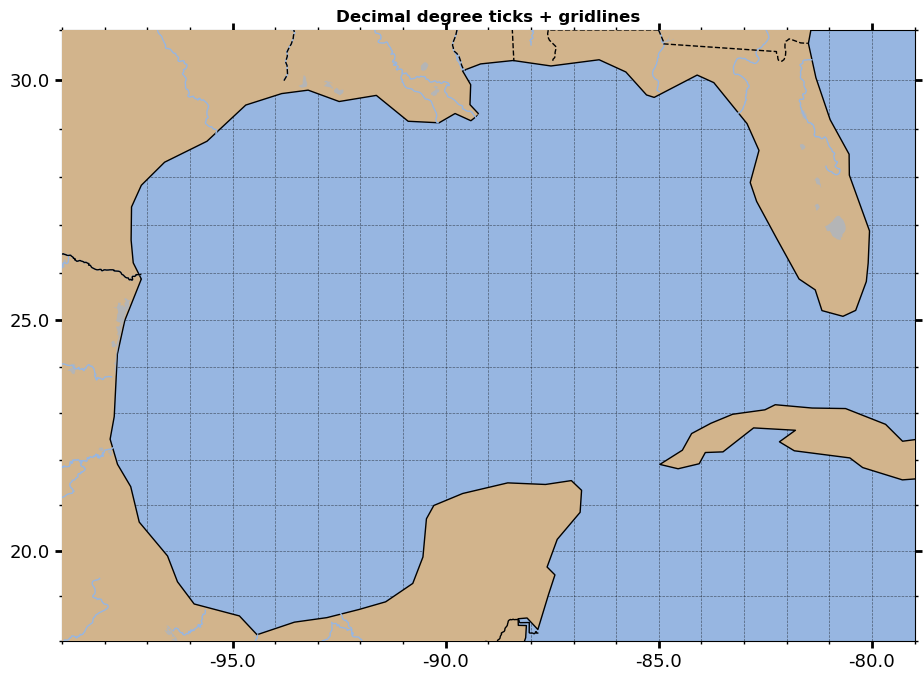

In [8]:
fig, ax = cplt.create(extent, coast="low", decimal_degrees=True, gridlines=True)
ax.set_title("Decimal degree ticks + gridlines", fontweight="bold")
plt.show()


---
## 7. Bathymetry

Set `bathymetry=True` to download bathymetry data (GEBCO, via the Rutgers ERDDAP/THREDDS server) for
your extent and overlay it. `isobaths=` picks which depths to contour, and `bathymetry_method=` picks
the rendering style:

| `bathymetry_method=`  | Description |
|-----------------------|--------------|
| `"contour"` (default) | Black isobath lines at each depth in `isobaths` |
| `"shadedcontour"`     | Isobaths shaded from light to dark grey with depth, plus a legend |
| `"banded"`            | Discrete depth bands filled with explicit colors (or a built-in default for the 3-band case), plus the usual isobath lines/labels and a legend |
| `"blues"`             | Continuous depth shading (Blues colormap); land masked out |
| `"blues_log"`         | Same, with a log-transformed depth scale |
| `"topo"`              | Continuous depth shading (cmocean `topo` colormap); land masked out |
| `"topofull"`          | Same as `"topo"`, but land elevation is shown too |

Bathymetry downloads are cached to disk after the first call, so repeated calls for the same extent are
fast. Very large extents are automatically split into 10-degree tiles before being requested from the
server (Rutgers THREDDS rejects single OpenDAP requests that are too large), then stitched back together
-- this is transparent when going through `create()`. If you call `get_bathymetry()` directly (see
`cool_maps.download`), pass `chunk_size=` (in degrees) to change the tile size, or `chunk_size=None` to
disable tiling.

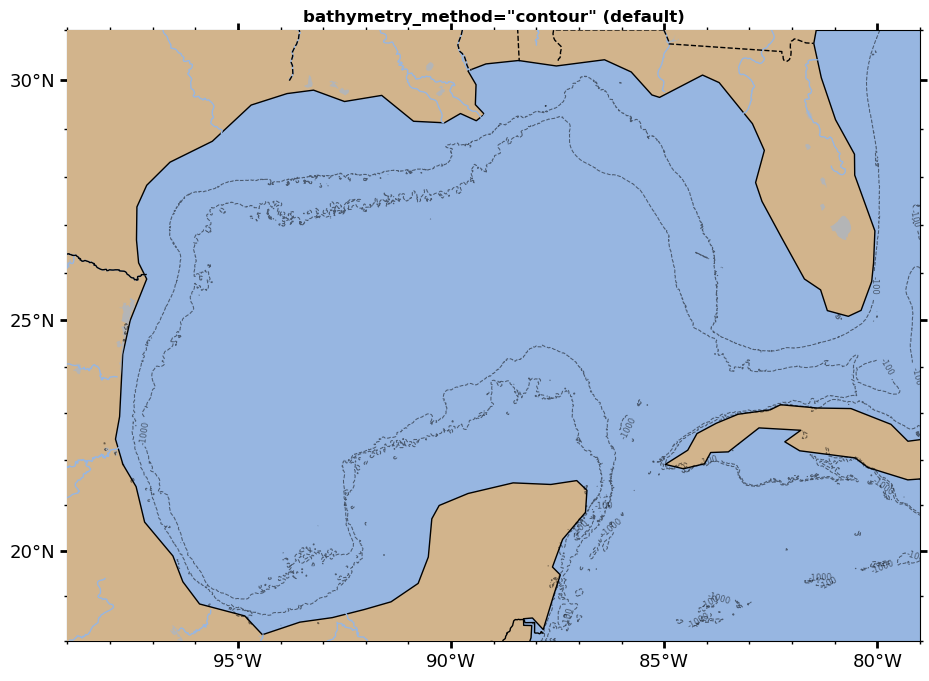

In [9]:
fig, ax = cplt.create(extent, coast="low", bathymetry=True, isobaths=(-1000, -100))
ax.set_title('bathymetry_method="contour" (default)', fontweight="bold")
plt.show()


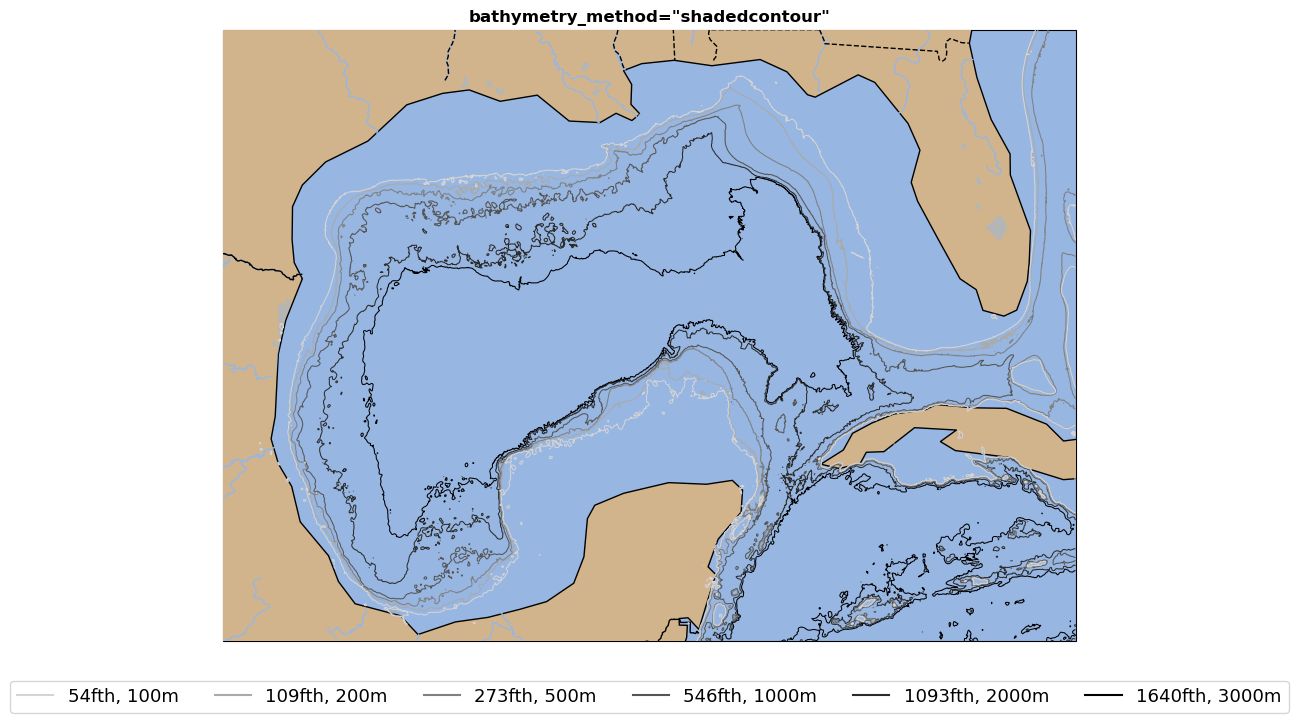

In [10]:
fig, ax = cplt.create(
    extent,
    coast="low",
    ticks=False,
    bathymetry=True,
    bathymetry_method="shadedcontour",
    isobaths=(-3000, -2000, -1000, -500, -200, -100),
)
ax.set_title('bathymetry_method="shadedcontour"', fontweight="bold")
plt.show()


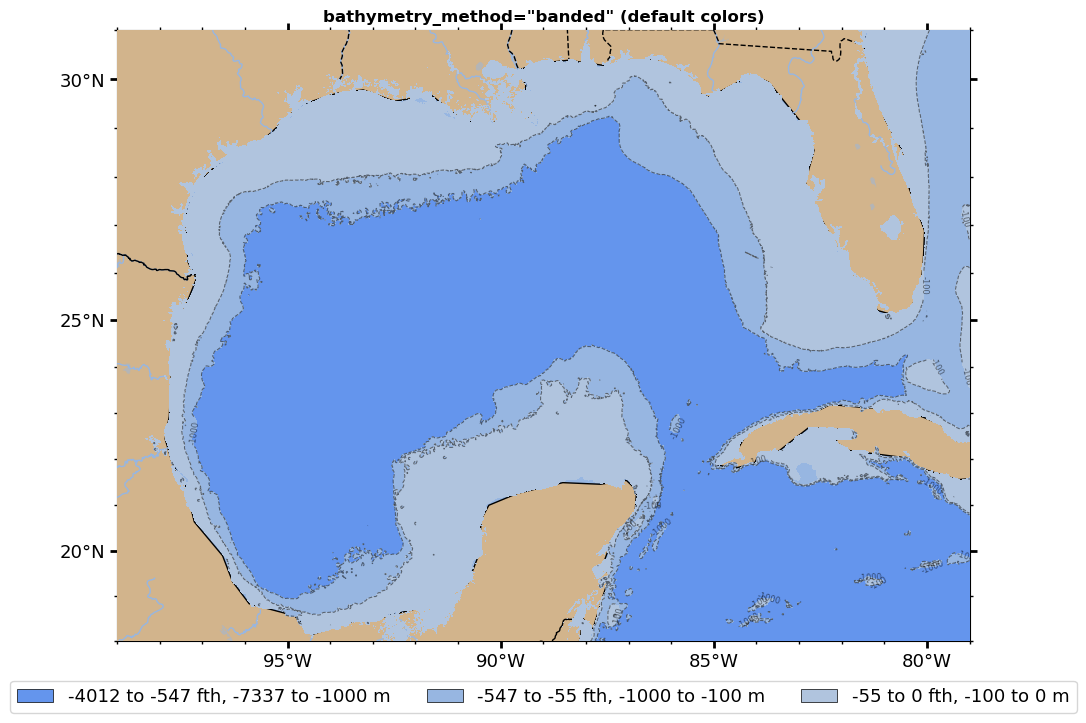

In [11]:
# The default isobaths=(-1000, -100) give exactly 3 bands, which has a built-in default
# color scheme (deep, cfeature.COLORS["water"] for the middle band, shallow) -- no
# bathymetry_colors= needed unless you want to customize it.
fig, ax = cplt.create(extent, coast="low", bathymetry=True, bathymetry_method="banded")
ax.set_title('bathymetry_method="banded" (default colors)', fontweight="bold")
plt.show()


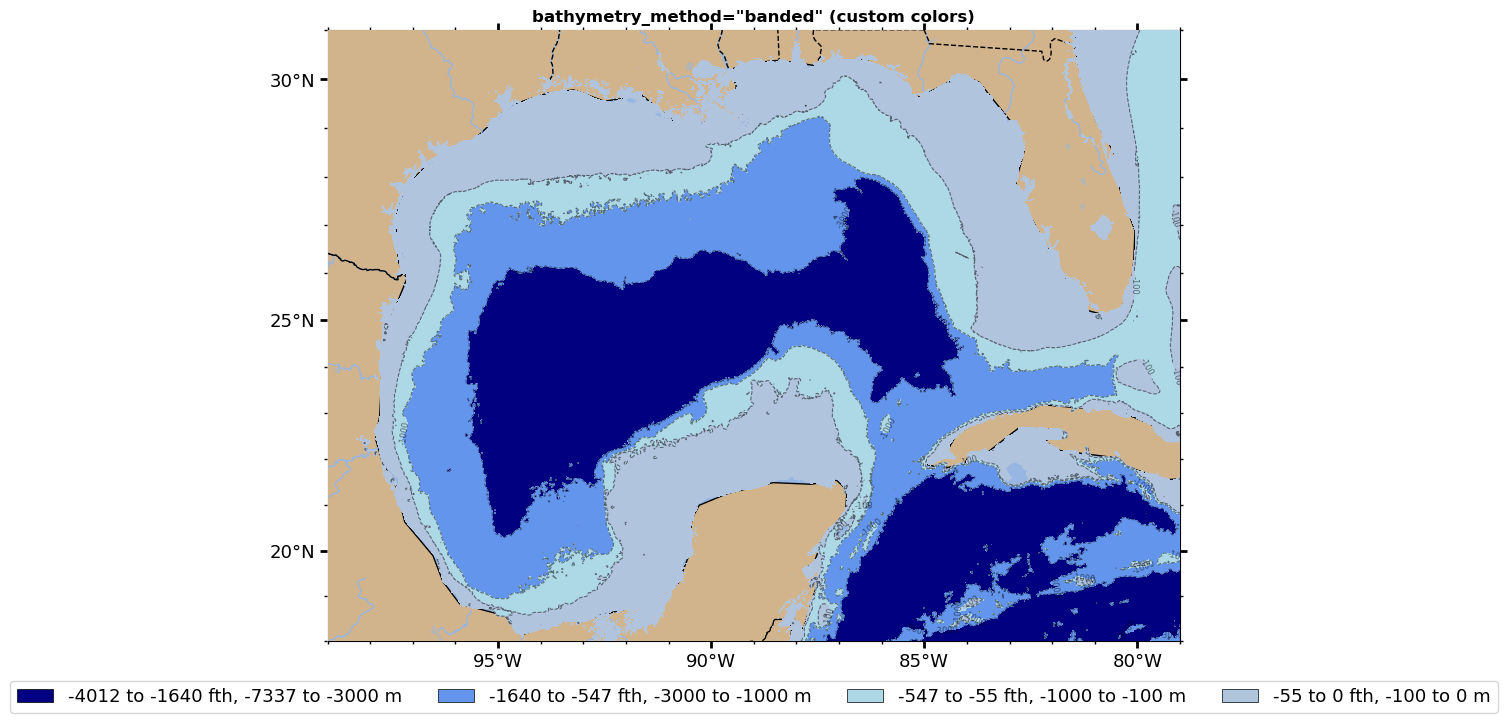

In [12]:
# Pass bathymetry_colors= (one more color than isobaths, deepest to shallowest) to customize
fig, ax = cplt.create(
    extent,
    coast="low",
    bathymetry=True,
    bathymetry_method="banded",
    isobaths=(-3000, -1000, -100),
    bathymetry_colors=["navy", "cornflowerblue", "lightblue", "lightsteelblue"],
)
ax.set_title('bathymetry_method="banded" (custom colors)', fontweight="bold")
plt.show()


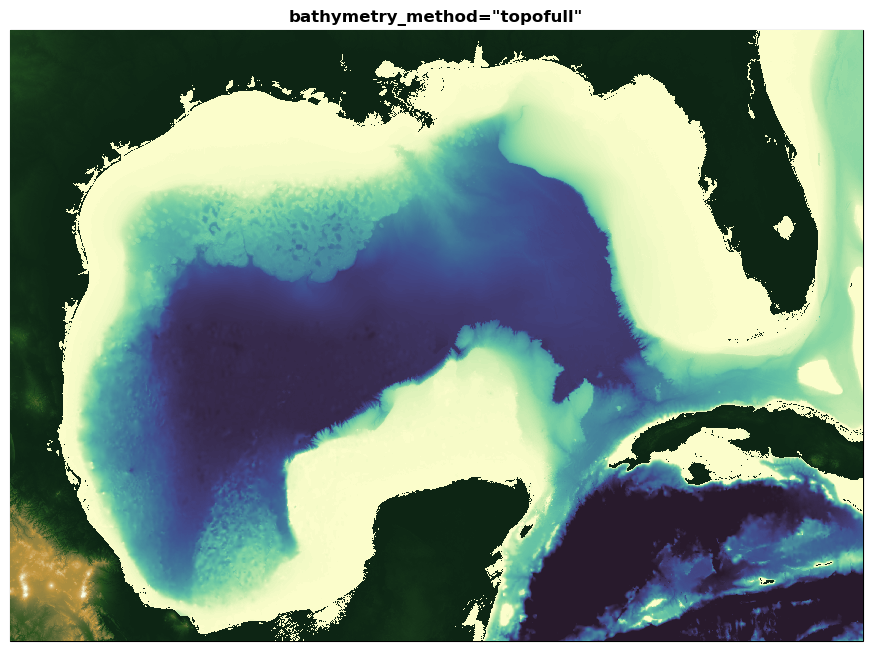

In [13]:
fig, ax = cplt.create(
    extent,
    coast="low",
    ticks=False,
    bathymetry=True,
    bathymetry_method="topofull",
    landcolor="none",  # let the topo colormap render land elevation too
)
ax.set_title('bathymetry_method="topofull"', fontweight="bold")
plt.show()


---
## 8. Overlaying your own data

`ax` (returned by `create()`) accepts plain longitude/latitude data directly on the usual matplotlib
plotting methods: `scatter`, `plot`, `contour`, `contourf`, `pcolormesh`, `quiver`, and `fill`.
`cool_maps` takes care of the coordinate-system detail behind the scenes (Cartopy needs a `transform=`
keyword; Basemap needs `latlon=True`) so you never have to think about it -- the same call works
regardless of which engine built the axes.

For point markers specifically, `add_marker()` is a thin convenience wrapper around the same idea.


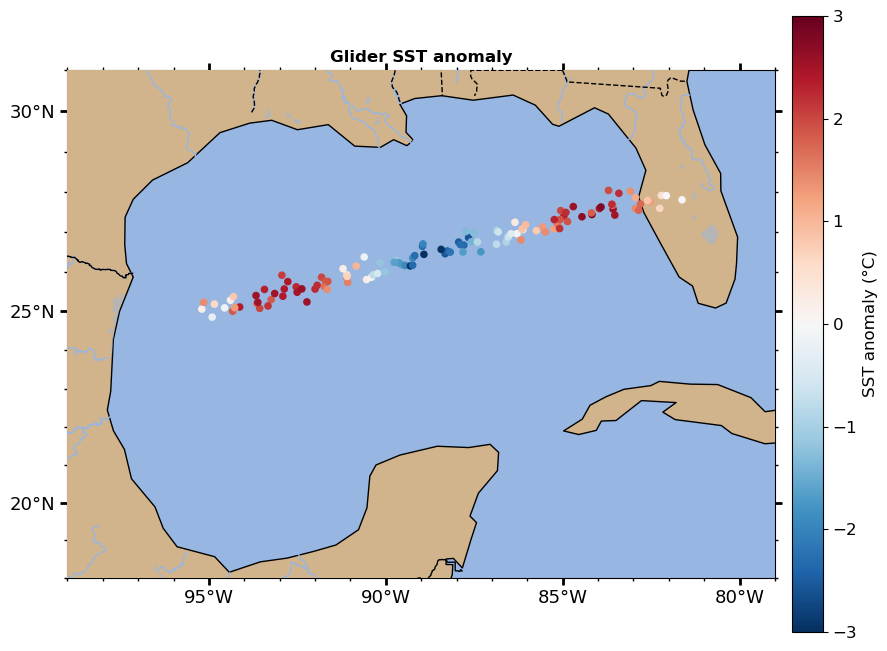

In [14]:
# Fake glider track with an SST anomaly reading at each point
rng = np.random.default_rng(42)
n = 120
lons = np.linspace(-95, -82, n) + rng.normal(0, 0.3, n)
lats = np.linspace(25, 28, n) + rng.normal(0, 0.15, n)
sst_anom = np.sin(np.linspace(0, 3 * np.pi, n)) * 2.5 + rng.normal(0, 0.3, n)

fig, ax = cplt.create(extent, coast="low")

sc = ax.scatter(lons, lats, c=sst_anom, cmap="RdBu_r", vmin=-3, vmax=3, s=20, zorder=200)
cplt.add_colorbar(ax, sc, label="SST anomaly (°C)")
ax.set_title("Glider SST anomaly", fontweight="bold")
plt.show()


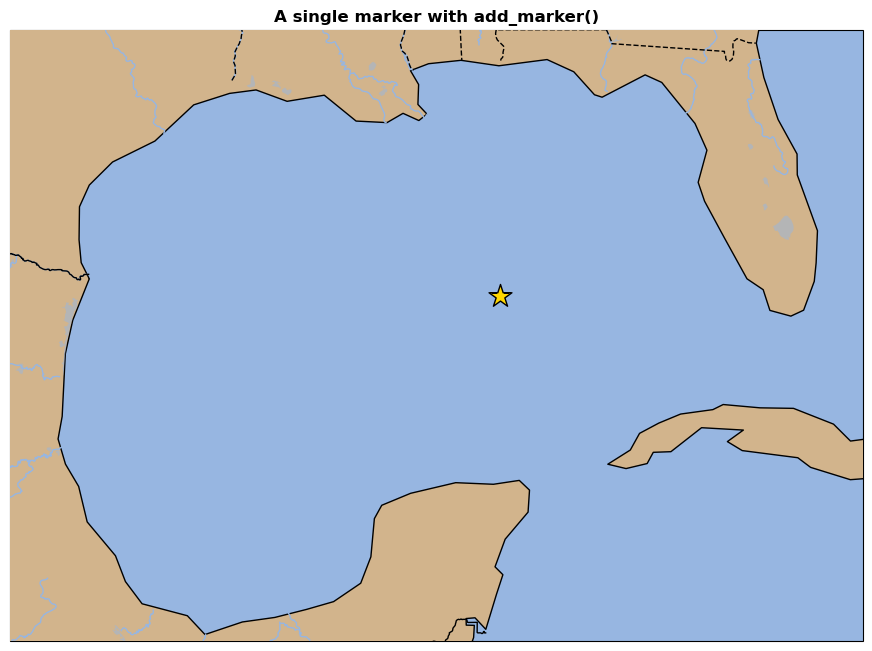

In [15]:
# add_marker() is a small convenience wrapper for point markers specifically
fig, ax = cplt.create(extent, coast="low", ticks=False)
cplt.add_marker(ax, lon=-87.5, lat=25.5, marker="*", color="gold", s=300, edgecolor="black", zorder=200)
ax.set_title("A single marker with add_marker()", fontweight="bold")
plt.show()


---
## 9. Ocean currents

`add_currents()` plots a quiver field from an `xarray.Dataset` containing `u`/`v` velocity components on
`lon`/`lat` (or `x`/`y`) coordinates. It coarsens the data first (via `coarsen=`) so the arrows stay
readable, and normalizes arrow length so only direction -- not raw magnitude -- is shown.


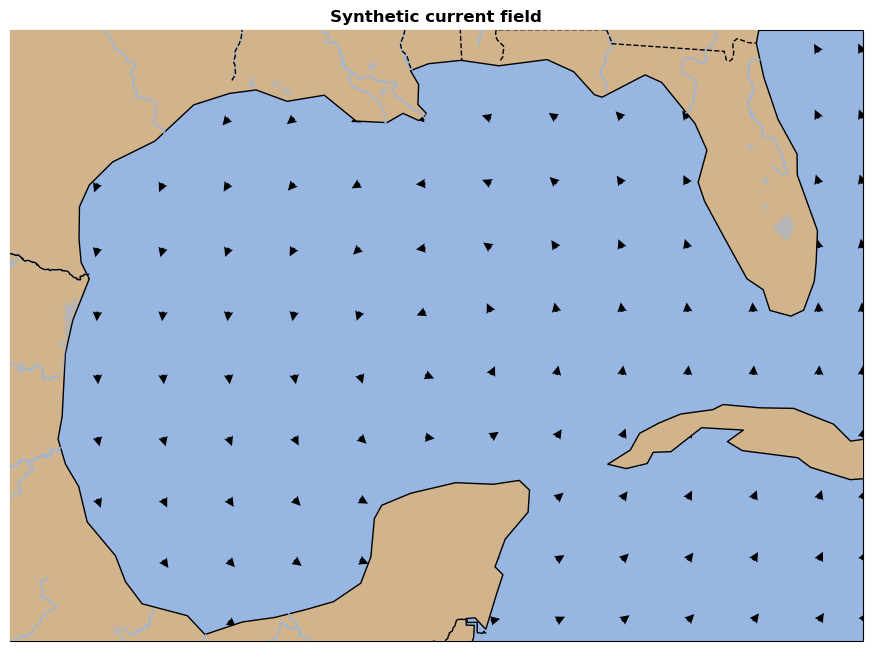

In [16]:
import xarray as xr

# Synthetic clockwise-ish current field over the extent (stand-in for real HFR/model output)
lon = np.linspace(extent[0], extent[1], 40)
lat = np.linspace(extent[2], extent[3], 30)
lon2d, lat2d = np.meshgrid(lon, lat)
u = -(lat2d - np.mean(lat))
v = (lon2d - np.mean(lon))

ds = xr.Dataset(
    {"u": (("lat", "lon"), u), "v": (("lat", "lon"), v)},
    coords={"lon": lon, "lat": lat},
)

fig, ax = cplt.create(extent, coast="low", ticks=False)
cplt.add_currents(ax, ds, coarsen=3)
ax.set_title("Synthetic current field", fontweight="bold")
plt.show()


---
## 10. Choosing between Cartopy and Basemap

Everything above works identically regardless of which engine is active. Cartopy is the default and the
only required dependency; Basemap is optional (`conda install -c conda-forge basemap basemap-data-hires`,
or `pip install cool_maps[basemap]`).

There are three ways to pick an engine:


In [17]:
# 1. Per call, with engine= -- doesn't touch the global default
fig, ax = cplt.create(extent, engine="cartopy", coast="low", ticks=False)
plt.close(fig)
print("Global engine after a per-call override:", cplt.get_engine())


Global engine after a per-call override: cartopy


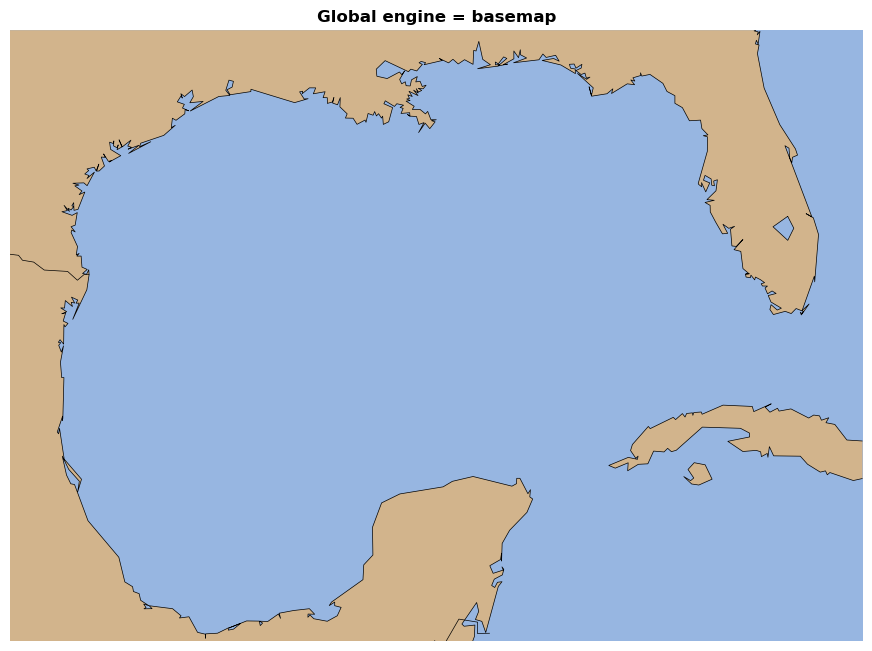

In [18]:
# 2. Globally, for the rest of the session
if "basemap" in cplt.available_engines():
    cplt.set_engine("basemap")
    fig, ax = cplt.create(extent, coast="low", ticks=False)
    ax.set_title("Global engine = basemap", fontweight="bold")
    plt.show()
    cplt.set_engine("cartopy")  # restore the default
else:
    print("Basemap isn't installed here -- skipping. See the markdown above for how to install it.")


3. Via the `COOL_MAPS_ENGINE` environment variable, set *before* you `import cool_maps.plot` (useful in
   scripts/notebooks you don't want to edit):

```bash
COOL_MAPS_ENGINE=basemap python my_script.py
```

One more thing worth knowing: the axes returned by `create()` remembers which engine built it, so you
never need to pass `engine=` to `add_features()` / `add_bathymetry()` / `add_currents()` / `add_ticks()`
yourself -- it's inferred from the axes automatically. You only need `engine=` when you want to *override*
what the axes would otherwise infer.


---
## 11. Building a map piece by piece

Setting `features=False` gives you a bare axes in the chosen projection, with none of the land/ocean/
border styling applied -- useful if you want full control, or want to apply the default styling with
different colors/resolution after the fact via `add_features()` (rather than reaching for engine-specific
methods like Cartopy's `ax.add_feature()`, which won't work if the axes turns out to be a Basemap axes).


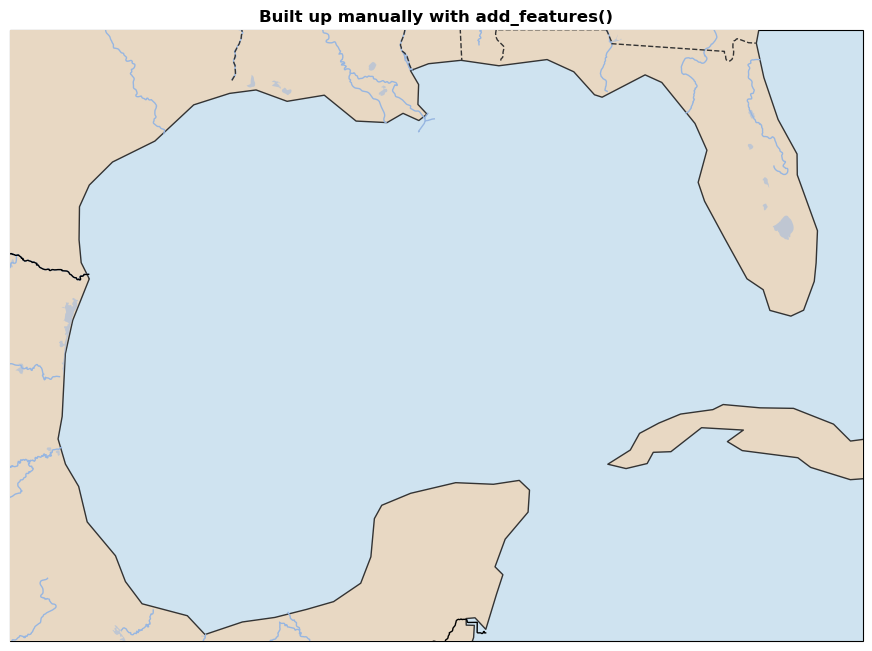

In [19]:
fig, ax = cplt.create(extent, features=False, ticks=False)

# add_features() is the engine-agnostic way to add the land/ocean/border styling back in,
# with whatever customization you want -- it works no matter which engine built `ax`.
cplt.add_features(ax, landcolor="#e8d8c3", oceancolor="#cfe3f0", edgecolor="#333333", coast="low")
ax.set_title("Built up manually with add_features()", fontweight="bold")
plt.show()


---
## 12. Saving your figures

`export_fig()` is a thin wrapper around `plt.savefig()` that trims the whitespace around the plot.


In [20]:
import tempfile

fig, ax = cplt.create(extent, coast="low")
with tempfile.TemporaryDirectory() as tmpdir:
    cplt.export_fig(tmpdir, "my_map.png")
    print("Saved to", tmpdir)
plt.close(fig)


Saved to /var/folders/mj/83cm4lyn3hjfj96pvymhyw1m0000gn/T/tmp3mp46xdi


`save_fig()` / `load_fig()` can pickle a whole figure for later reuse, but note that a figure's
engine-specific instrumentation (and, for Basemap, the attached `Basemap` object) is not guaranteed to
survive a pickle round-trip -- treat a reloaded figure's axes as plain matplotlib axes rather than a
fully re-instrumented `cool_maps` axes.


---
## 13. Where to go next

- Full API reference: every function's docstring, via `help(cplt)` or the
  [hosted documentation](https://cool-maps.readthedocs.io/en/latest/).
- `notebooks/dual_backend_demo.ipynb` -- a deeper dive into Cartopy/Basemap parity, including a
  performance comparison between the two engines.
- `notebooks/engine_demo.ipynb` -- a minimal smoke test that both engines render without errors.
